<a href="https://colab.research.google.com/github/IssadaornNK/Spaceship-Titanic/blob/main/spaceshipTitanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================
# IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from google.colab import files

# =========================================
# UPLOAD DATA
# =========================================
uploaded = files.upload()

# =========================================
# LOAD DATA
# =========================================
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Saving test.csv to test (1).csv
Saving train.csv to train (2).csv
Train shape: (8693, 14)
Test shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
# =========================================
# BASIC DATA OVERVIEW
# =========================================

print("=== INFO ===")
train_df.info()

print("\n=== MISSING VALUES ===")
print(train_df.isnull().sum())

print("\n=== DATA TYPES ===")
print(train_df.dtypes)

print("\n=== DESCRIPTIVE STATS ===")
display(train_df.describe(include="all"))

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8693 non-null   object 
 2   CryoSleep     8693 non-null   object 
 3   Cabin         8693 non-null   object 
 4   Destination   8693 non-null   object 
 5   Age           8693 non-null   float64
 6   VIP           8693 non-null   object 
 7   RoomService   8693 non-null   float64
 8   FoodCourt     8693 non-null   float64
 9   ShoppingMall  8693 non-null   float64
 10  Spa           8693 non-null   float64
 11  VRDeck        8693 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
 14  Group         8693 non-null   object 
 15  GroupSize     8693 non-null   int64  
 16  Deck          8693 non-null   object 
 17  CabinNum      8494 non-null   object 
 18  Side          8

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Name,Transported,Group,GroupSize,Deck,CabinNum,Side,TotalSpend,NoSpending,LastName
count,8693,8693,8693,8693,8693,8693.000000,8693,8693.000000,8693.000000,8693.000000,...,8493,8693,8693,8693.000000,8693,8494,8494,8693.000000,8693.000000,8493
unique,8693,4,3,6561,4,NaN,3,NaN,NaN,NaN,...,8473,2,6217,NaN,9,1817,2,NaN,NaN,2217
top,9280_02,Earth,False,Unknown,TRAPPIST-1e,NaN,False,NaN,NaN,NaN,...,Ankalik Nateansive,True,9081,NaN,F,82,S,NaN,NaN,Casonston
freq,1,4602,5439,199,5915,NaN,8291,NaN,NaN,NaN,...,2,4378,8,NaN,2794,28,4288,NaN,NaN,18
mean,NaN,NaN,NaN,NaN,NaN,28.790291,NaN,220.009318,448.434027,169.572300,...,NaN,NaN,NaN,2.035546,NaN,NaN,NaN,1440.866329,0.420223,NaN
std,NaN,NaN,NaN,NaN,NaN,14.341404,NaN,660.519050,1595.790627,598.007164,...,NaN,NaN,NaN,1.596347,NaN,NaN,NaN,2803.045694,0.493623,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,20.000000,NaN,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,716.000000,0.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,37.000000,NaN,41.000000,61.000000,22.000000,...,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,1441.000000,1.000000,NaN


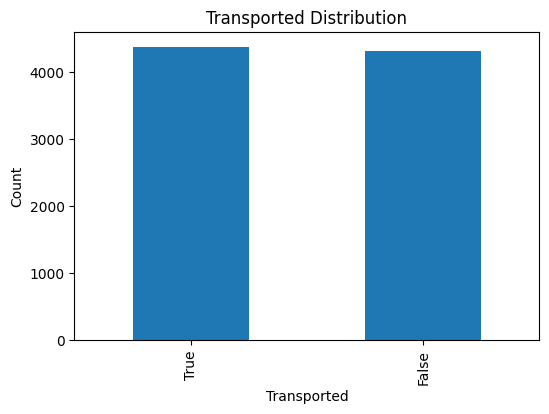

Target proportion:
Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


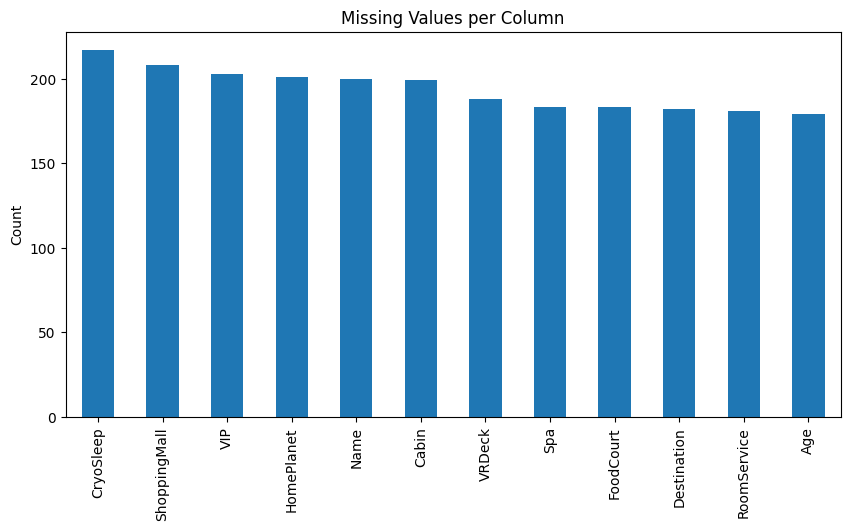

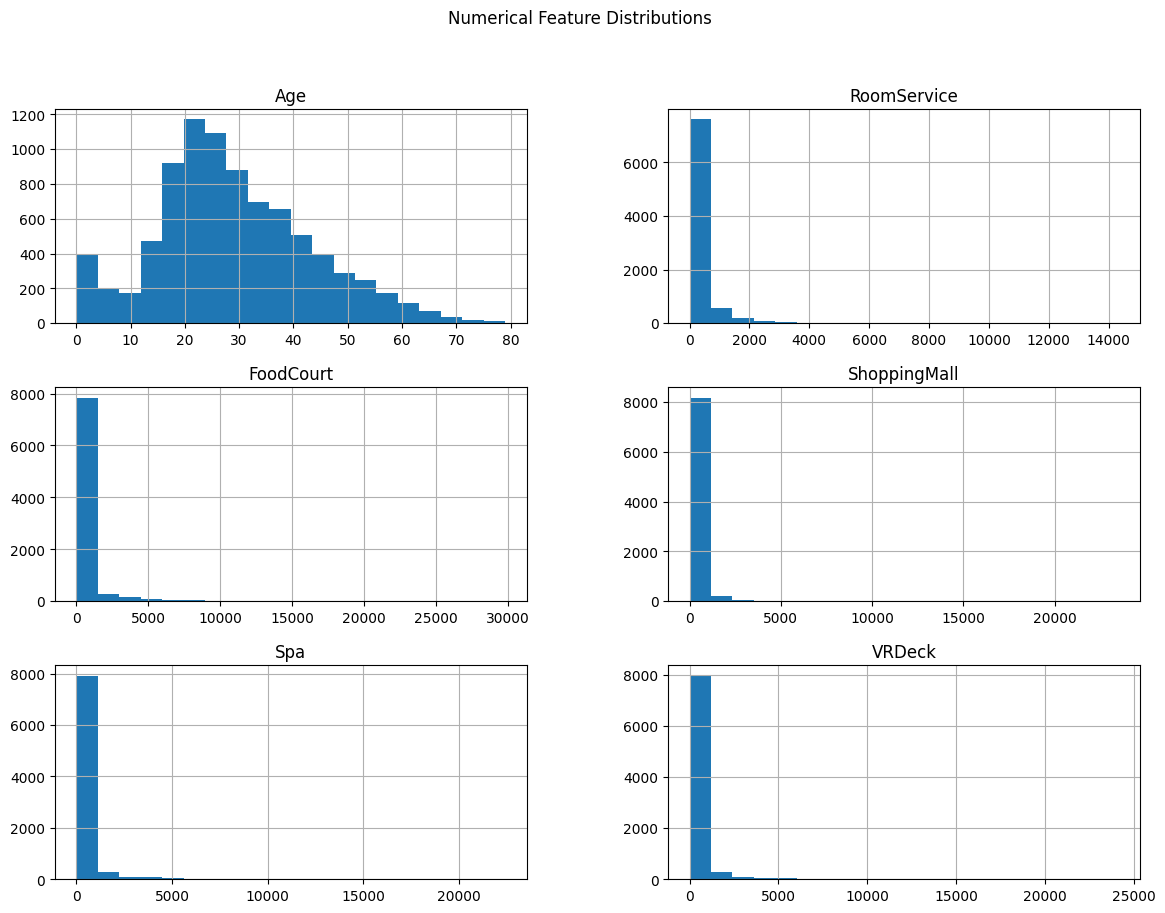

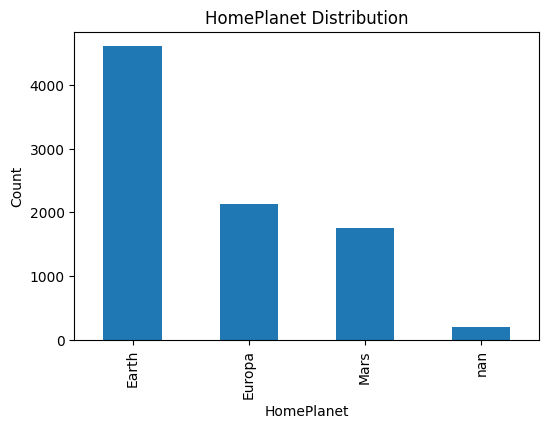

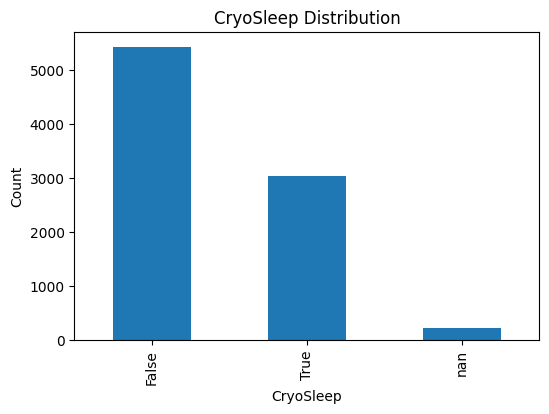

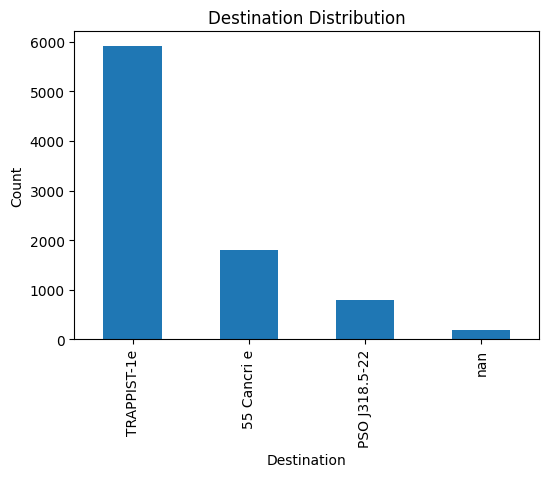

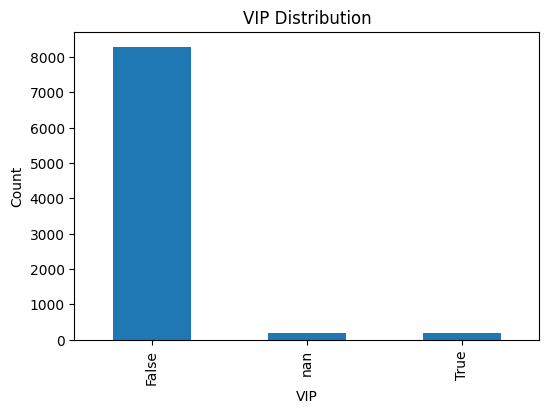

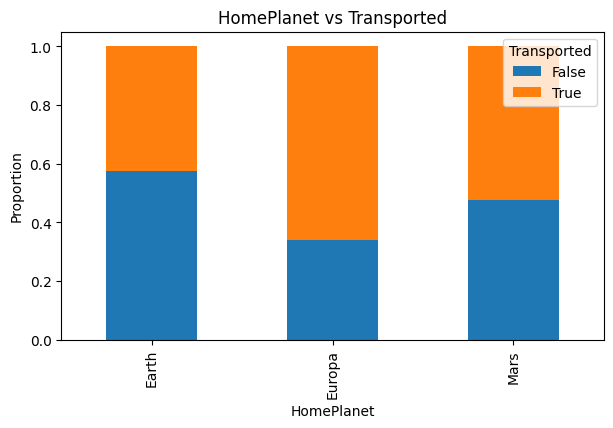

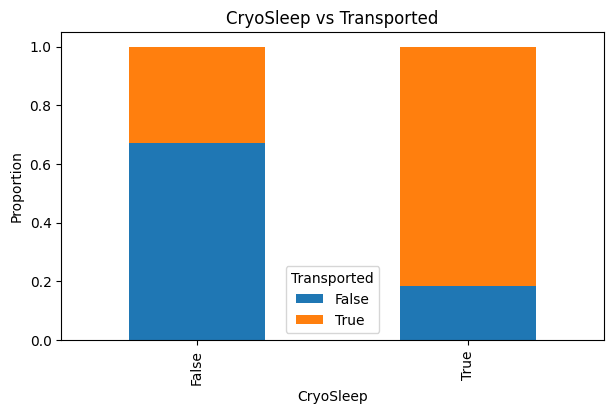

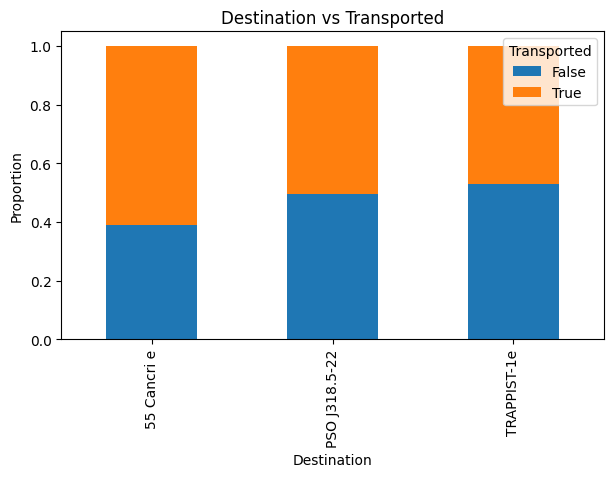

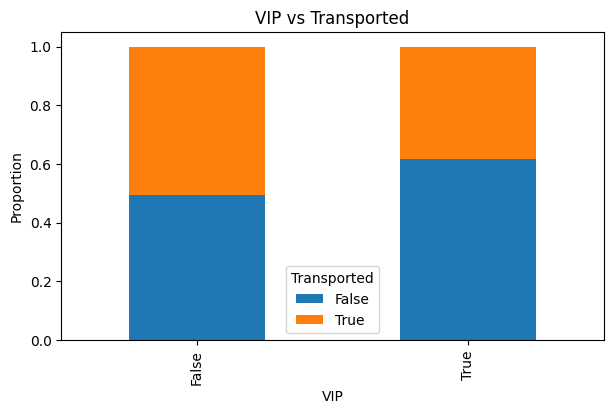

In [ ]:
# =========================================
# EDA VISUALIZATION
# =========================================

# 1. Target distribution
plt.figure(figsize=(6,4))
train_df["Transported"].value_counts().plot(kind="bar")
plt.title("Transported Distribution")
plt.xlabel("Transported")
plt.ylabel("Count")
plt.show()

print("Target proportion:")
print(train_df["Transported"].value_counts(normalize=True))


# 2. Missing values
missing = train_df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(10,5))
missing.plot(kind="bar")
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.show()


# 3. Numerical distributions
num_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

train_df[num_cols].hist(figsize=(14,10), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()


# 4. Categorical distributions
cat_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    train_df[col].value_counts(dropna=False).plot(kind="bar")
    plt.title(f"{col} Distribution")
    plt.ylabel("Count")
    plt.show()


# 5. Relationship with target
for col in cat_cols:
    cross_tab = pd.crosstab(train_df[col], train_df["Transported"], normalize="index")
    cross_tab.plot(kind="bar", stacked=True, figsize=(7,4))
    plt.title(f"{col} vs Transported")
    plt.ylabel("Proportion")
    plt.show()

In [ ]:
# =========================================
# DATA CLEANING
# =========================================

print("Missing before cleaning:")
print(train_df.isnull().sum())

# Fill Cabin with Unknown
train_df["Cabin"] = train_df["Cabin"].fillna("Unknown")
test_df["Cabin"] = test_df["Cabin"].fillna("Unknown")

# Fill categorical columns
cat_basic = ["HomePlanet", "CryoSleep", "Destination", "VIP"]

for col in cat_basic:
    train_df[col] = train_df[col].fillna("Unknown")
    test_df[col] = test_df[col].fillna("Unknown")

# Fill Age
train_df["Age"] = train_df["Age"].fillna(train_df["Age"].median())
test_df["Age"] = test_df["Age"].fillna(test_df["Age"].median())

print("\nMissing after cleaning:")
print(train_df.isnull().sum())

Missing before cleaning:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

Missing after cleaning:
PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin             0
Destination       0
Age               0
VIP               0
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


In [ ]:
# =========================================
# FEATURE ENGINEERING
# =========================================

def feature_engineering(df):
    df = df.copy()

    # Group features
    df["Group"] = df["PassengerId"].str.split("_").str[0]
    df["GroupSize"] = df["Group"].map(df["Group"].value_counts())

    # Cabin features
    df["Deck"] = df["Cabin"].str.split("/").str[0]
    df["CabinNum"] = df["Cabin"].str.split("/").str[1]
    df["Side"] = df["Cabin"].str.split("/").str[2]

    # Spending features
    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    df[spend_cols] = df[spend_cols].fillna(0)
    df["TotalSpend"] = df[spend_cols].sum(axis=1)

    # No spending
    df["NoSpending"] = (df["TotalSpend"] == 0).astype(int)

    # Last name
    df["LastName"] = df["Name"].str.split().str[-1]

    return df

train_df = feature_engineering(train_df)
test_df = feature_engineering(test_df)

print("Feature engineering done")
train_df.head()

Feature engineering done


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Name,Transported,Group,GroupSize,Deck,CabinNum,Side,TotalSpend,NoSpending,LastName
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,Maham Ofracculy,False,0001,1,B,0,P,0.0,1,Ofracculy
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,Juanna Vines,True,0002,1,F,0,S,736.0,0,Vines
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,Altark Susent,False,0003,2,A,0,S,10383.0,0,Susent
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,Solam Susent,False,0003,2,A,0,S,5176.0,0,Susent
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,Willy Santantines,True,0004,1,F,1,S,1091.0,0,Santantines


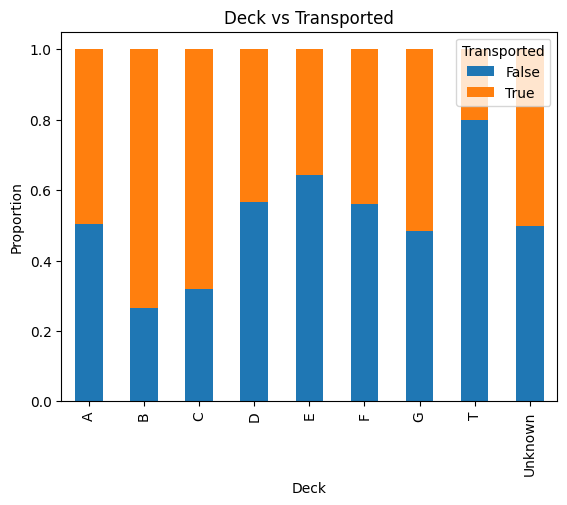

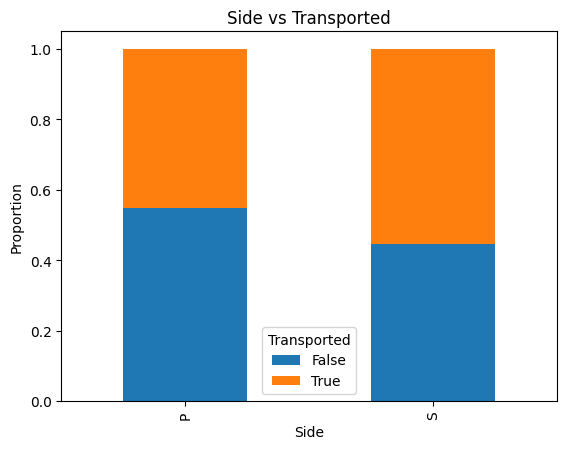

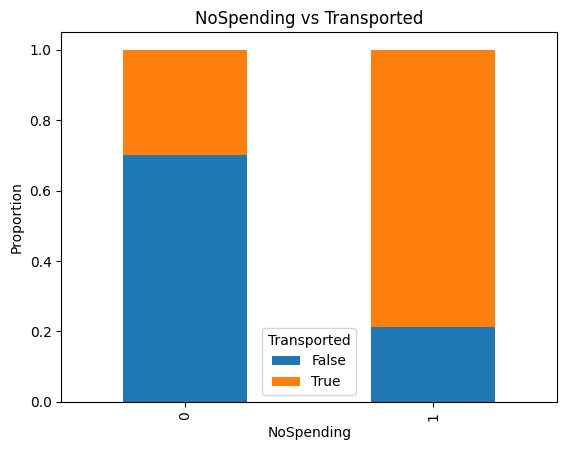

In [ ]:
# =========================================
# EDA ON NEW FEATURES
# =========================================

for col in ["Deck", "Side", "NoSpending"]:
    cross_tab = pd.crosstab(train_df[col], train_df["Transported"], normalize="index")
    cross_tab.plot(kind="bar", stacked=True)
    plt.title(f"{col} vs Transported")
    plt.ylabel("Proportion")
    plt.show()

In [ ]:
# =========================================
# DATA PREPARATION
# =========================================

from sklearn.model_selection import train_test_split

# Drop unnecessary columns
drop_cols = ["PassengerId", "Name", "Cabin", "Group", "LastName"]

X = train_df.drop(columns=["Transported"] + drop_cols, errors="ignore")
y = train_df["Transported"]

X_test_final = test_df.drop(columns=drop_cols, errors="ignore")

print("Training features shape:", X.shape)
print("Test features shape:", X_test_final.shape)

# Identify column types
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

# Fix type issue (important)
for col in categorical_cols:
    X[col] = X[col].astype("object")
    X_test_final[col] = X_test_final[col].astype("object")

# Train-validation split (for later modeling)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nX_train:", X_train.shape)
print("X_val:", X_val.shape)

Training features shape: (8693, 16)
Test features shape: (4277, 16)

Categorical columns: ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'CabinNum', 'Side']
Numerical columns: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupSize', 'TotalSpend', 'NoSpending']

X_train: (6954, 16)
X_val: (1739, 16)


In [ ]:
# =========================================
# PREPARE DATA FOR CATBOOST
# =========================================

# Rebuild X and test features if needed
drop_cols = ["PassengerId", "Name", "Cabin", "Group", "LastName"]

X = train_df.drop(columns=["Transported"] + drop_cols, errors="ignore")
y = train_df["Transported"]

X_test_final = test_df.drop(columns=drop_cols, errors="ignore")

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

# Fill missing values in categorical columns and convert to string
for col in categorical_cols:
    X[col] = X[col].fillna("Unknown").astype(str)
    X_test_final[col] = X_test_final[col].fillna("Unknown").astype(str)

# Optional: fill missing numeric values for stability
for col in numerical_cols:
    X[col] = X[col].fillna(X[col].median())
    X_test_final[col] = X_test_final[col].fillna(X_test_final[col].median())

# Train-validation split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

# Double-check missing values
print("\nMissing values in categorical train columns:")
print(X_train[categorical_cols].isnull().sum())

print("\nMissing values in categorical validation columns:")
print(X_val[categorical_cols].isnull().sum())

Categorical columns: ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'CabinNum', 'Side']
Numerical columns: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupSize', 'TotalSpend', 'NoSpending']
X_train shape: (6954, 16)
X_val shape: (1739, 16)

Missing values in categorical train columns:
HomePlanet     0
CryoSleep      0
Destination    0
VIP            0
Deck           0
CabinNum       0
Side           0
dtype: int64

Missing values in categorical validation columns:
HomePlanet     0
CryoSleep      0
Destination    0
VIP            0
Deck           0
CabinNum       0
Side           0
dtype: int64


In [ ]:
# =========================================
# CATBOOST MODEL
# =========================================

!pip install -q catboost

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    loss_function="Logloss",
    eval_metric="Accuracy",
    verbose=100
)

model.fit(
    X_train, y_train,
    cat_features=categorical_cols,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

y_pred = model.predict(X_val)

print("\n=== VALIDATION RESULTS ===")
print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

0:	learn: 0.7602819	test: 0.7544566	best: 0.7544566 (0)	total: 77.1ms	remaining: 38.5s
100:	learn: 0.8247052	test: 0.8027602	best: 0.8067855 (69)	total: 2.06s	remaining: 8.14s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8067855089
bestIteration = 69

Shrink model to first 70 iterations.

=== VALIDATION RESULTS ===
Accuracy: 0.8067855089131685
              precision    recall  f1-score   support

       False       0.81      0.80      0.80       863
        True       0.80      0.81      0.81       876

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739



In [ ]:
# =========================================
# FINAL SUBMISSION (KAGGLE SAFE)
# =========================================

from google.colab import files
import pandas as pd

# Predict on test set
test_preds = model.predict(X_test_final)

# Convert predictions safely to True/False
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"].values,
    "Transported": pd.Series(test_preds).astype(str).map(lambda x: True if x == "True" else False)
})

# Save CSV (NO index!)
submission.to_csv("submission.csv", index=False)

# Preview
print(submission.head())
print("\nValue counts:")
print(submission["Transported"].value_counts())

print("\nData types:")
print(submission.dtypes)

# Download file
files.download("submission.csv")

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True

Value counts:
Transported
True     2220
False    2057
Name: count, dtype: int64

Data types:
PassengerId    object
Transported      bool
dtype: object


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Accuracy: 0.8067855089131685

Classification Report:
              precision    recall  f1-score   support

       False       0.81      0.80      0.80       863
        True       0.80      0.81      0.81       876

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739



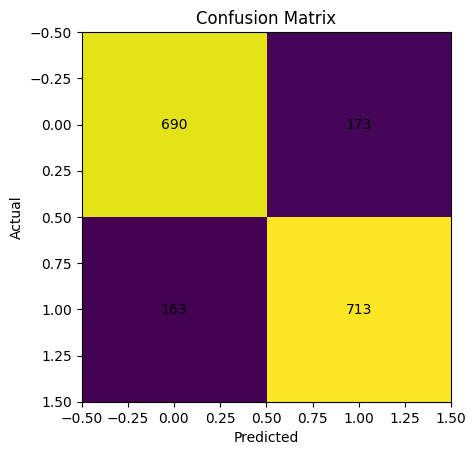

In [ ]:
# =========================================
# MODEL EVALUATION
# =========================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Accuracy
print("Accuracy:", accuracy_score(y_val, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()